# Curve-vs-Vol Basis — Backtest

Mean-reversion fade of the pair basis (traded curve vs option-implied median path),
expressed as a 4-leg risk-reversal spread between the legs, **marked on listed wing
premiums at strikes fixed at entry**, lag-1 execution, flat per-trade cost.

Edit `BACKTEST_CONFIG` below and re-run — everything downstream (header block, equity
panels, trade log, exit comparison, honesty panel) recomputes.

In [1]:
import sys; sys.path.append("../../")

import dataclasses
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

from RVUtils.FlyVsVol.pair_backtest import (
    PairBacktestConfig, prepare_data, run_pair_backtest,
)

DATA = Path("../data/fly_vs_vol")
wings = pd.read_parquet(DATA / "wing_premiums.parquet")
contracts = pd.read_parquet(DATA / "contracts.parquet")
data = prepare_data(wings, contracts)

# ---- BACKTEST_CONFIG: tweak freely ------------------------------------------
BACKTEST_CONFIG = PairBacktestConfig(
    basis="premium",          # 'premium' = listed marks (honest) | 'skew' = model marks
    ma=5,                      # signal smoothing (days)
    zscore_window=120,         # rolling z window
    zscore_min_periods=40,
    entry_min_zscore=2.0,      # fade entries beyond this |z|
    exit_style="z0",          # 'z0' cross-zero | 'half' |z|<=0.5 | 't10' 10d
    exit_max_holding_days=20,
    stop_loss_bp=None,         # e.g. 8.0 for a hard stop on package marks
    lag=1,                     # execution lag (days) — keep 1 for honesty
    round_trip_cost_bp=2.5,    # 4-leg package, taker
    quality_gate=True,
    pairs=None,                # e.g. ('SFRU26-SFRZ26', 'SFRZ26-SFRH27') to restrict
)
res = run_pair_backtest(BACKTEST_CONFIG, data=data)

m = res.metrics
d0 = res.daily_pnl.index.min() if len(res.daily_pnl) else None
d1 = res.daily_pnl.index.max() if len(res.daily_pnl) else None
print("=" * 88)
print(f"CURVE-VS-VOL BASIS BACKTEST | {BACKTEST_CONFIG.label()}")
print("=" * 88)
print(f"  Period          : {d0} -> {d1}")
print(f"  Pairs           : {res.trades['label'].nunique() if len(res.trades) else 0} traded")
print(f"  Entries         : {m['n_trades']}")
print(f"  Total net P&L   : {m['total_net_bp']:+.2f} bp   (avg {m['avg_net_bp']:+.2f}/trade)")
print(f"  Hit rate        : {m['hit_rate']:.0%}")
print(f"  Sharpe (daily)  : {m['sharpe']:.2f}")
print(f"  Max drawdown    : {m['max_dd_bp']:+.2f} bp")
print(f"  Avg holding     : {m['avg_hold_days']:.1f} days   worst trade {m['worst_bp']:+.2f} bp")

CURVE-VS-VOL BASIS BACKTEST | premium|ma5|w120|z2.0|z0|lag1
  Period          : 2025-08-08 00:00:00 -> 2026-07-27 00:00:00
  Pairs           : 4 traded
  Entries         : 6
  Total net P&L   : -13.00 bp   (avg -2.17/trade)
  Hit rate        : 17%
  Sharpe (daily)  : -2.26
  Max drawdown    : -15.25 bp
  Avg holding     : 12.3 days   worst trade -6.50 bp


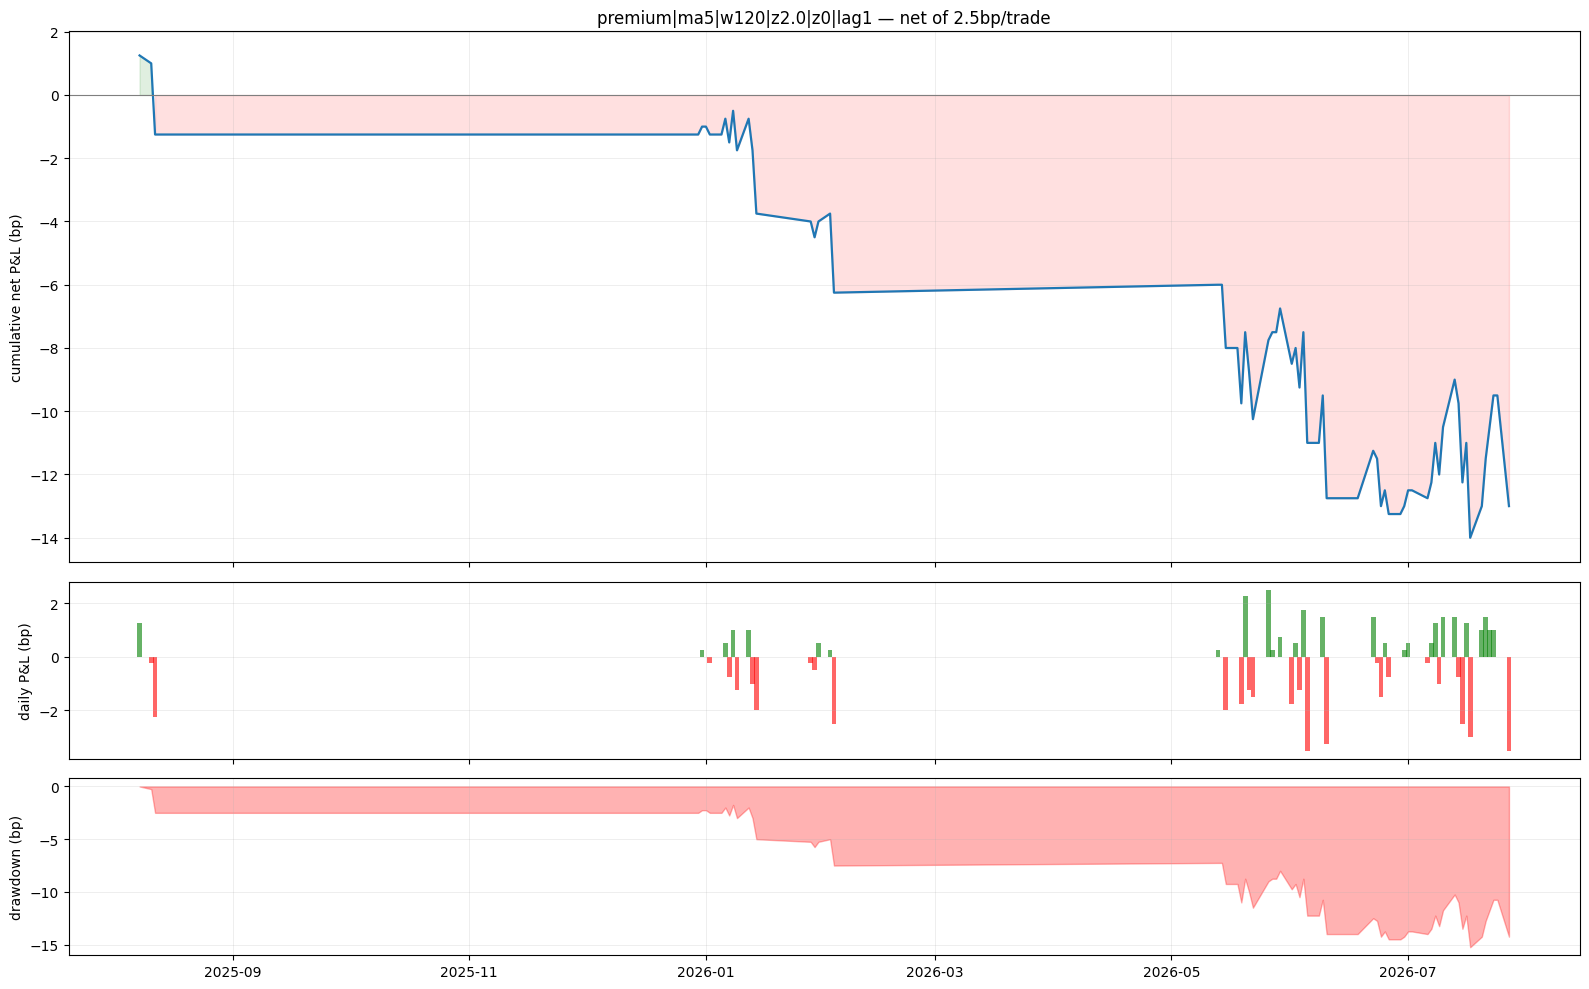

In [2]:
daily = res.daily_pnl
cum = daily.cumsum()
dd = cum - cum.cummax()
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1, 1]})
axes[0].plot(cum.index, cum.values, color="#1f77b4", linewidth=1.6)
axes[0].fill_between(cum.index, cum.values, 0, where=cum.values >= 0,
                      color="green", alpha=0.12)
axes[0].fill_between(cum.index, cum.values, 0, where=cum.values < 0,
                      color="red", alpha=0.12)
axes[0].axhline(0, color="#7f7f7f", linewidth=0.8)
axes[0].set_ylabel("cumulative net P&L (bp)")
axes[0].set_title(f"{BACKTEST_CONFIG.label()} — net of {BACKTEST_CONFIG.round_trip_cost_bp}bp/trade")
axes[1].bar(daily.index, daily.values, width=1.2,
            color=np.where(daily.values >= 0, "green", "red"), alpha=0.6)
axes[1].set_ylabel("daily P&L (bp)")
axes[2].fill_between(dd.index, dd.values, 0, color="red", alpha=0.3)
axes[2].set_ylabel("drawdown (bp)")
for ax in axes:
    ax.grid(True, alpha=0.25, linewidth=0.6)
plt.tight_layout()
plt.show()

In [3]:
if len(res.trades):
    print("trade log:")
    print(res.trades.sort_values("entry").to_string(index=False))
    print("\nexit reasons:")
    print(res.trades["exit_reason"].value_counts().to_string())
    print("\nper-pair breakdown (net bp):")
    bp = res.trades.groupby("label")["net_bp"].agg(["count", "sum", "mean"])
    bp["hit"] = res.trades.groupby("label")["net_bp"].apply(lambda s: (s > 0).mean())
    print(bp.round(2).to_string())

trade log:
        label  dir signal_date      entry       exit  days  z_in  gross_bp  net_bp    exit_reason
SFRM27-SFRU27    1  2025-08-06 2025-08-07 2025-08-12     3 -2.40      1.25   -1.25 mean_reversion
SFRM27-SFRU27    1  2025-12-26 2025-12-29 2026-01-14    12 -2.20      0.00   -2.50 mean_reversion
SFRM27-SFRU27    1  2026-01-26 2026-01-27 2026-02-03     5 -2.36      0.00   -2.50 mean_reversion
SFRU26-SFRZ26   -1  2026-05-11 2026-05-12 2026-06-10    20  2.28     -4.00   -6.50       max_hold
SFRH27-SFRM27    1  2026-06-16 2026-06-17 2026-07-17    20 -2.09      1.25   -1.25       max_hold
SFRZ26-SFRH27    1  2026-07-06 2026-07-07 2026-07-27    14 -2.26      3.50    1.00            eod

exit reasons:
exit_reason
mean_reversion    3
max_hold          2
eod               1

per-pair breakdown (net bp):
               count   sum  mean  hit
label                                
SFRH27-SFRM27      1 -1.25 -1.25  0.0
SFRM27-SFRU27      3 -6.25 -2.08  0.0
SFRU26-SFRZ26      1 -6.50 -6.50  

## Exit-strategy comparison

                       n_trades  total_net_bp  hit_rate  avg_net_bp  sharpe  max_dd_bp  avg_hold_days  worst_bp
Strategy                                                                                                       
mean-reversion (z0)           6        -13.00      0.17       -2.17   -2.26     -15.25          12.33     -6.50
take-profit (|z|<0.5)         6        -13.50      0.17       -2.25   -2.62     -16.75          10.17     -6.50
time stop (10d)               8        -21.25      0.00       -2.66   -3.94     -22.50           9.00     -4.25
z0 + stop 8bp                 6        -13.00      0.17       -2.17   -2.26     -15.25          12.33     -6.50


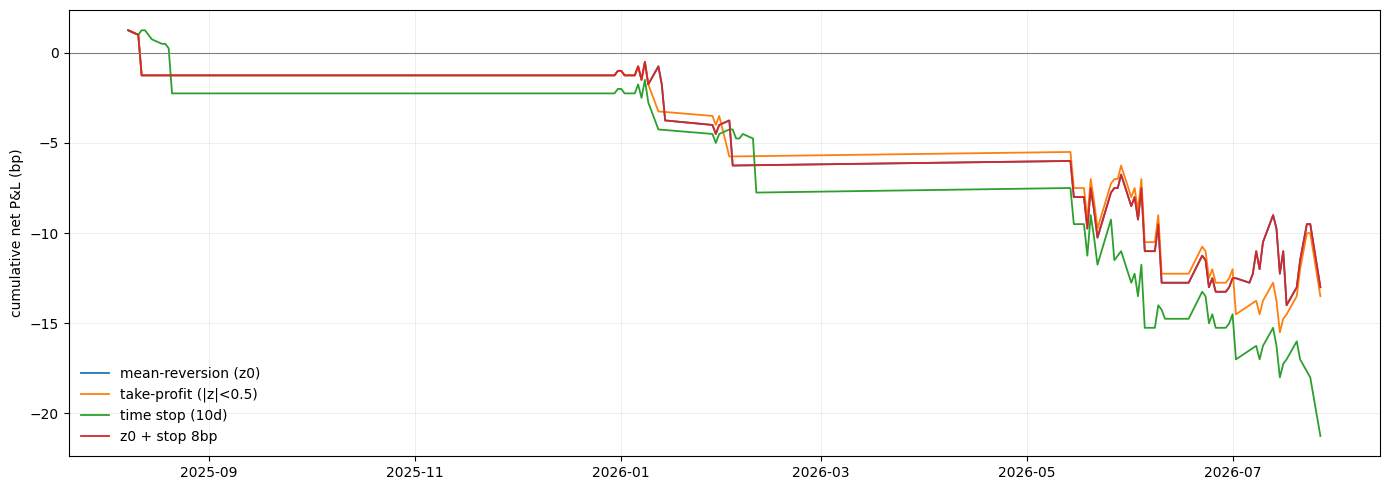

In [4]:
exit_configs = {
    "mean-reversion (z0)": dataclasses.replace(BACKTEST_CONFIG, exit_style="z0"),
    "take-profit (|z|<0.5)": dataclasses.replace(BACKTEST_CONFIG, exit_style="half"),
    "time stop (10d)": dataclasses.replace(BACKTEST_CONFIG, exit_style="t10"),
    "z0 + stop 8bp": dataclasses.replace(BACKTEST_CONFIG, exit_style="z0",
                                          stop_loss_bp=8.0),
}
rows, curves = [], {}
for name, cfg in exit_configs.items():
    r = run_pair_backtest(cfg, data=data)
    rows.append({"Strategy": name, **{k: round(v, 2) for k, v in r.metrics.items()}})
    curves[name] = r.daily_pnl.cumsum()
summary = pd.DataFrame(rows).set_index("Strategy")
print(summary.to_string())

fig, ax = plt.subplots(figsize=(14, 5))
for name, c in curves.items():
    ax.plot(c.index, c.values, linewidth=1.3, label=name)
ax.axhline(0, color="#7f7f7f", linewidth=0.8)
ax.set_ylabel("cumulative net P&L (bp)")
ax.legend(frameon=False)
ax.grid(True, alpha=0.25, linewidth=0.6)
plt.tight_layout()
plt.show()

## Honesty panel — marks and execution lag

The same config on model marks vs listed-premium marks, same-bar vs lagged execution.
The gap between the `skew`/`lag0` cell and the `premium`/`lag1` cell is the part of any
apparent edge that does not survive contact with executable prices.

In [5]:
grid = {}
for basis in ("skew", "premium"):
    for lag in (0, 1):
        r = run_pair_backtest(dataclasses.replace(BACKTEST_CONFIG, basis=basis, lag=lag),
                              data=data)
        grid[(basis, f"lag{lag}")] = {
            "total_net_bp": round(r.metrics["total_net_bp"], 1),
            "n": r.metrics["n_trades"], "hit": round(r.metrics["hit_rate"], 2)
            if r.metrics["n_trades"] else np.nan,
        }
print(pd.DataFrame(grid).T.to_string())

              total_net_bp    n   hit
skew    lag0           4.2  5.0  0.80
        lag1           4.0  4.0  0.50
premium lag0         -14.8  6.0  0.17
        lag1         -13.0  6.0  0.17


## Caveats

- Risk-neutral / one-regime sample (2025-06..2026-07, a hiking-then-pause cycle).
- Wing settle premiums are executable-adjacent, not bid/ask; residual wing delta is
  unhedged between entry and exit.
- Findings to date: the basis mean-reverts (VR(5)~0.3) and the fade is gross-positive,
  but per-trade gross runs below the 4-leg taker cost. Doors that could change the
  verdict: 2-leg digital-calendar expressions (~1.2bp cost), FOMC event-window entries,
  maker execution.